In [1]:
import pandas as pd

df = pd.read_csv("/content/api_data_aadhar_biometric_0_500000.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 500000
Columns: 6


,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,01-03-2025,Haryana,Mahendragarh,123029,280,577
1,01-03-2025,Bihar,Madhepura,852121,144,369
2,01-03-2025,Jammu and Kashmir,Punch,185101,643,1091
3,01-03-2025,Bihar,Bhojpur,802158,256,980
4,01-03-2025,Tamil Nadu,Madurai,625514,271,815


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   date          500000 non-null  object
 1   state         500000 non-null  object
 2   district      500000 non-null  object
 3   pincode       500000 non-null  int64 
 4   bio_age_5_17  500000 non-null  int64 
 5   bio_age_17_   500000 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 22.9+ MB


In [3]:
df.isnull().sum()

,0
date,0
state,0
district,0
pincode,0
bio_age_5_17,0
bio_age_17_,0


In [5]:
df.duplicated().sum()

np.int64(10318)

In [6]:
df = df.drop_duplicates().reset_index(drop=True)

print("Duplicates removed successfully!")
print("Remaining rows:", len(df))

Duplicates removed successfully!
Remaining rows: 489682


In [7]:
print("Negative bio_age_5_17 values:", (df["bio_age_5_17"] < 0).sum())
print("Negative bio_age_17_ values:", (df["bio_age_17_"] < 0).sum())

Negative bio_age_5_17 values: 0
Negative bio_age_17_ values: 0


In [8]:
print("Date data type:", df["date"].dtype)
print("Invalid dates:", df["date"].isna().sum())
print("Start date:", df["date"].min())
print("End date:", df["date"].max())

Date data type: object
Invalid dates: 0
Start date: 01-03-2025
End date: 19-09-2025


In [9]:
print("Number of states:", df["state"].nunique())
print("Number of districts:", df["district"].nunique())

print("\nTop 10 states:")
print(df["state"].value_counts().head(10))

print("\nTop 10 districts:")
print(df["district"].value_counts().head(10))

Number of states: 56
Number of districts: 945

Top 10 states:
state
Tamil Nadu        46297
Andhra Pradesh    42937
Uttar Pradesh     42253
Maharashtra       39425
Karnataka         37598
West Bengal       36067
Kerala            24803
Gujarat           24292
Odisha            23995
Bihar             22293
Name: count, dtype: int64

Top 10 districts:
district
Pune                 3144
North 24 Parganas    2975
Barddhaman           2921
Thrissur             2843
East Godavari        2762
Warangal             2703
Hyderabad            2487
Palakkad             2447
Karimnagar           2436
Bengaluru            2416
Name: count, dtype: int64


In [10]:
states = sorted(df["state"].dropna().unique())

for state in states:
    print(state)

Andaman & Nicobar Islands
Andaman and Nicobar Islands
Andhra Pradesh
Arunachal Pradesh
Assam
Bihar
Chandigarh
Chhatisgarh
Chhattisgarh
Dadra & Nagar Haveli
Dadra and Nagar Haveli
Dadra and Nagar Haveli and Daman and Diu
Daman & Diu
Daman and Diu
Delhi
Goa
Gujarat
Haryana
Himachal Pradesh
Jammu & Kashmir
Jammu and Kashmir
Jharkhand
Karnataka
Kerala
Ladakh
Lakshadweep
Madhya Pradesh
Maharashtra
Manipur
Meghalaya
Mizoram
Nagaland
ODISHA
Odisha
Orissa
Pondicherry
Puducherry
Punjab
Rajasthan
Sikkim
Tamil Nadu
Telangana
Tripura
Uttar Pradesh
Uttarakhand
Uttaranchal
WEST BENGAL
WESTBENGAL
West  Bengal
West Bangal
West Bengal
West bengal
Westbengal
andhra pradesh
odisha
west Bengal


In [11]:
districts = sorted(df["district"].dropna().unique())

print("Total districts:", len(districts))

for district in districts[:100]:
    print(district)

Total districts: 945
ANUGUL
Adilabad
Agar Malwa
Agra
Ahmadabad
Ahmadnagar
Ahmed Nagar
Ahmedabad
Aizawl
Ajmer
Akola
Alappuzha
Aligarh
Alipurduar
Alirajpur
Allahabad
Alluri Sitharama Raju
Almora
Alwar
Ambala
Ambedkar Nagar
Amethi
Amravati
Amreli
Amritsar
Amroha
Anakapalli
Anand
Anantapur
Ananthapur
Ananthapuramu
Anantnag
Andamans
Angul
Anjaw
Annamayya
Anugul
Anuppur
Araria
Ariyalur
Arvalli
Arwal
Ashok Nagar
Auraiya
Aurangabad
Aurangabad(bh)
Ayodhya
Azamgarh
BALANGIR
Badgam
Bagalkot
Bagalkot *
Bageshwar
Baghpat
Bagpat
Bahraich
Bajali
Baksa
Balaghat
Balangir
Baleshwar
Baleswar
Ballari
Ballia
Bally Jagachha
Balod
Baloda Bazar
Balrampur
Banas Kantha
Banaskantha
Banda
Bandipore
Bangalore
Bangalore Rural
Banka
Bankura
Banswara
Bapatla
Bara Banki
Barabanki
Baramula
Baran
Barddhaman
Bardez
Bardhaman
Bareilly
Bargarh
Barmer
Barnala
Barpeta
Barwani
Bastar
Basti
Bathinda
Baudh
Beed
Begusarai
Belagavi
Belgaum
Bellary


In [13]:
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")

print("Date type:", df["date"].dtype)
print("Invalid dates:", df["date"].isna().sum())
print("Start date:", df["date"].min())
print("End date:", df["date"].max())

Date type: datetime64[ns]
Invalid dates: 0
Start date: 2025-03-01 00:00:00
End date: 2025-09-19 00:00:00


In [14]:
df["total_mbu"] = (
    df["bio_age_5_17"] +
    df["bio_age_17_"]
)

df[[
    "bio_age_5_17",
    "bio_age_17_",
    "total_mbu"
]].head()

,bio_age_5_17,bio_age_17_,total_mbu
0,280,577,857
1,144,369,513
2,643,1091,1734
3,256,980,1236
4,271,815,1086


In [15]:
df["total_mbu"].describe()

,total_mbu
count,489682.000000
mean,99.218611
std,305.122737
min,0.000000
25%,3.000000
50%,11.000000
75%,53.000000
max,13381.000000


In [16]:
state_analysis = (
    df.groupby("state")
      .agg(
          first_mbu=("bio_age_5_17", "sum"),
          second_mbu=("bio_age_17_", "sum"),
          total_mbu=("total_mbu", "sum")
      )
      .reset_index()
)

state_analysis = state_analysis.sort_values(
    "total_mbu",
    ascending=False
)

state_analysis.head(15)

,state,first_mbu,second_mbu,total_mbu
43,Uttar Pradesh,4394770,2248859,6643629
27,Maharashtra,2291649,3711089,6002738
26,Madhya Pradesh,2534702,2066563,4601265
5,Bihar,1650778,1892655,3543433
40,Tamil Nadu,1257656,1768833,3026489
38,Rajasthan,1496095,1347939,2844034
2,Andhra Pradesh,1580665,976833,2557498
16,Gujarat,1108517,1346670,2455187
22,Karnataka,863100,1009714,1872814
50,West Bengal,748185,1028613,1776798


In [17]:
print("Total First MBU:", df["bio_age_5_17"].sum())
print("Total Second MBU:", df["bio_age_17_"].sum())
print("Total MBU:", df["total_mbu"].sum())

Total First MBU: 23430272
Total Second MBU: 25155296
Total MBU: 48585568


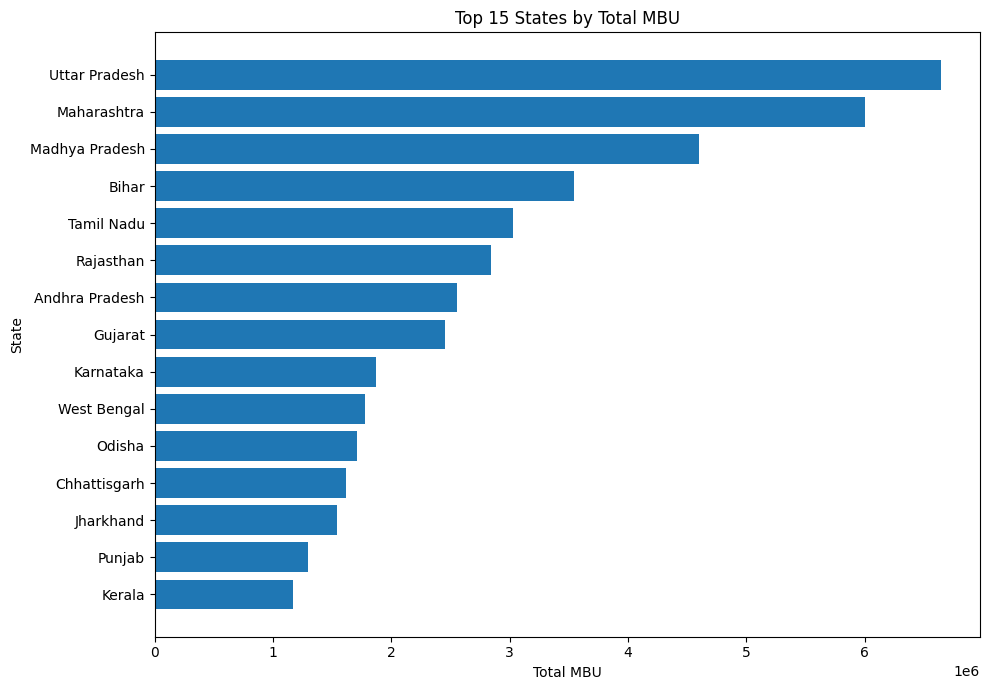

In [18]:
import matplotlib.pyplot as plt

top_states = state_analysis.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_states["state"],
    top_states["total_mbu"]
)

plt.xlabel("Total MBU")
plt.ylabel("State")
plt.title("Top 15 States by Total MBU")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [19]:
district_analysis = (
    df.groupby(["state", "district"])
      .agg(
          first_mbu=("bio_age_5_17", "sum"),
          second_mbu=("bio_age_17_", "sum"),
          total_mbu=("total_mbu", "sum")
      )
      .reset_index()
      .sort_values("total_mbu", ascending=False)
)

district_analysis.head(20)

,state,district,first_mbu,second_mbu,total_mbu
539,Maharashtra,Pune,177468,223803,401271
535,Maharashtra,Nashik,142839,227438,370277
548,Maharashtra,Thane,117045,238633,355678
229,Gujarat,Ahmedabad,124112,188348,312460
523,Maharashtra,Jalgaon,100056,178830,278886
527,Maharashtra,Mumbai,73061,182556,255617
218,Delhi,North West Delhi,100520,154990,255510
739,Rajasthan,Jaipur,110395,143073,253468
28,Andhra Pradesh,Kurnool,179112,70123,249235
531,Maharashtra,Nagpur,75507,160655,236162


In [20]:
print(
    district_analysis[
        ["state", "district", "total_mbu"]
    ].head(20).to_string(index=False)
)

         state         district  total_mbu
   Maharashtra             Pune     401271
   Maharashtra           Nashik     370277
   Maharashtra            Thane     355678
       Gujarat        Ahmedabad     312460
   Maharashtra          Jalgaon     278886
   Maharashtra           Mumbai     255617
         Delhi North West Delhi     255510
     Rajasthan           Jaipur     253468
Andhra Pradesh          Kurnool     249235
   Maharashtra           Nagpur     236162
   Maharashtra          Solapur     228939
Andhra Pradesh    Visakhapatnam     226913
   Maharashtra           Nanded     226452
   Maharashtra       Ahmadnagar     226423
   Maharashtra         Amravati     225451
     Karnataka        Bengaluru     216421
       Gujarat            Surat     207376
   Maharashtra       Aurangabad     204831
Andhra Pradesh    East Godavari     204117
Andhra Pradesh           Guntur     202271


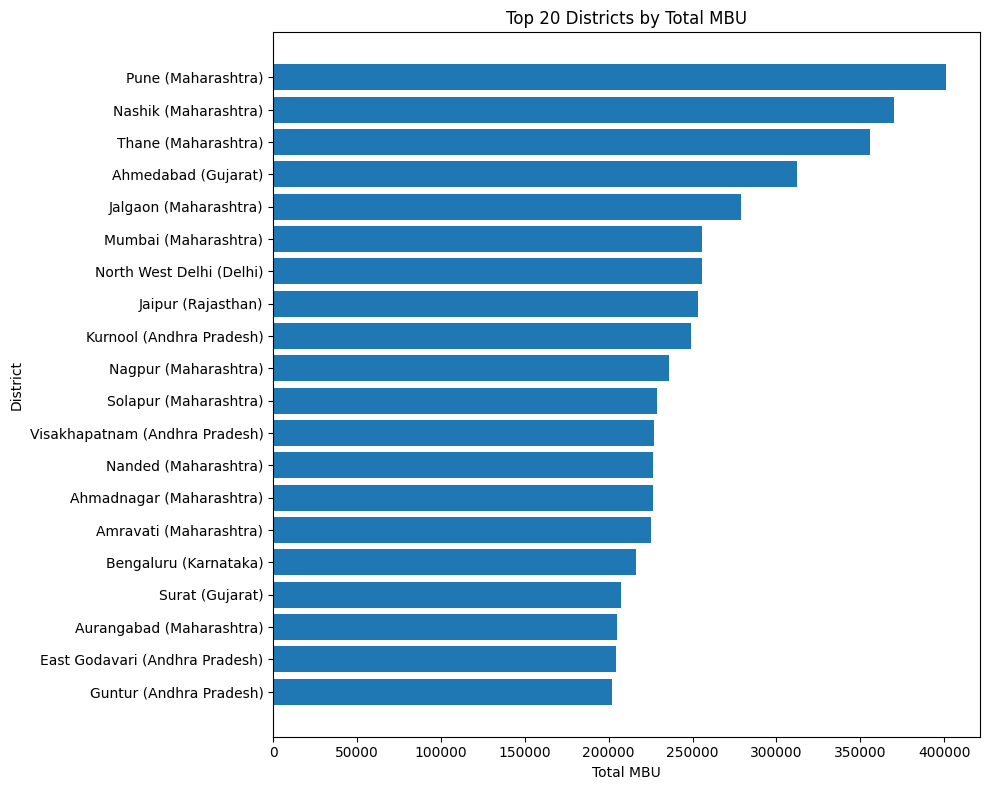

In [21]:
top_districts = district_analysis.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_districts["district"] + " (" + top_districts["state"] + ")",
    top_districts["total_mbu"]
)

plt.xlabel("Total MBU")
plt.ylabel("District")
plt.title("Top 20 Districts by Total MBU")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

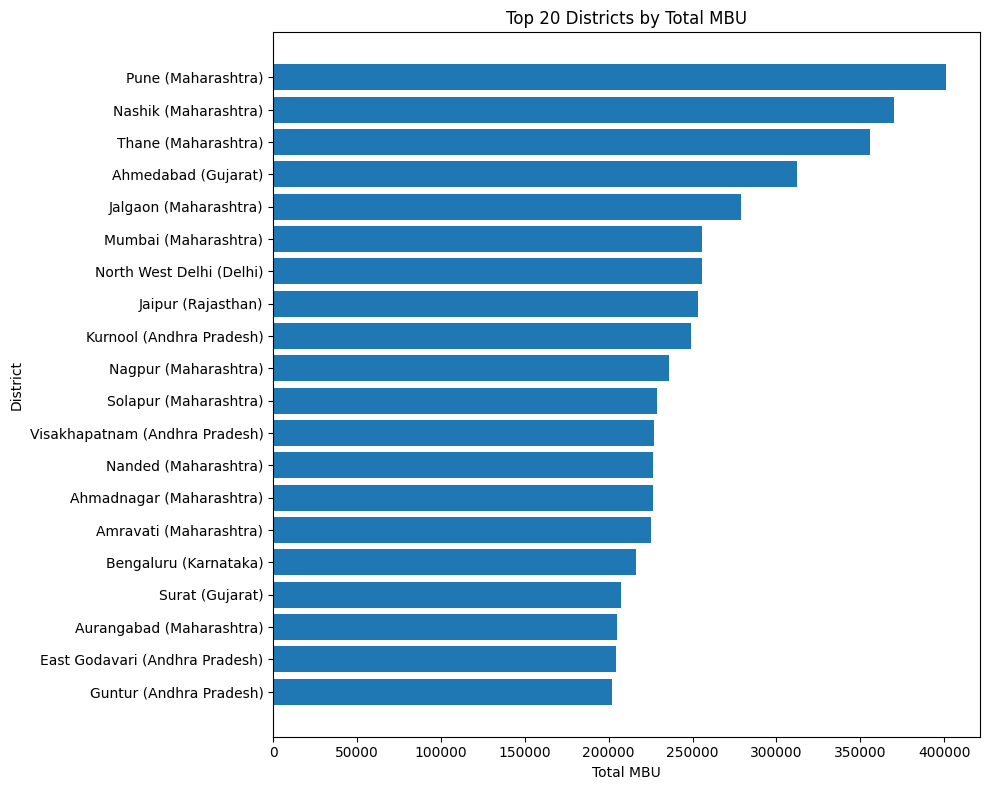

In [22]:
top_districts = district_analysis.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_districts["district"] + " (" + top_districts["state"] + ")",
    top_districts["total_mbu"]
)

plt.xlabel("Total MBU")
plt.ylabel("District")
plt.title("Top 20 Districts by Total MBU")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "/content/top_20_districts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
mbu_comparison = (
    df.groupby("state")
      .agg(
          first_mbu=("bio_age_5_17", "sum"),
          second_mbu=("bio_age_17_", "sum")
      )
      .reset_index()
)

mbu_comparison["difference"] = (
    mbu_comparison["second_mbu"] -
    mbu_comparison["first_mbu"]
)

mbu_comparison.sort_values(
    "difference",
    ascending=False
).head(10)

,state,first_mbu,second_mbu,difference
27,Maharashtra,2291649,3711089,1419440
8,Chhattisgarh,348113,1273404,925291
40,Tamil Nadu,1257656,1768833,511177
37,Punjab,482275,813618,331343
50,West Bengal,748185,1028613,280428
5,Bihar,1650778,1892655,241877
16,Gujarat,1108517,1346670,238153
17,Haryana,466297,681238,214941
23,Kerala,478174,690982,212808
21,Jharkhand,667940,877699,209759


In [25]:
overall_mbu = pd.DataFrame({
    "MBU Type": ["First MBU", "Second MBU"],
    "Count": [
        df["bio_age_5_17"].sum(),
        df["bio_age_17_"].sum()
    ]
})

overall_mbu

,MBU Type,Count
0,First MBU,23430272
1,Second MBU,25155296


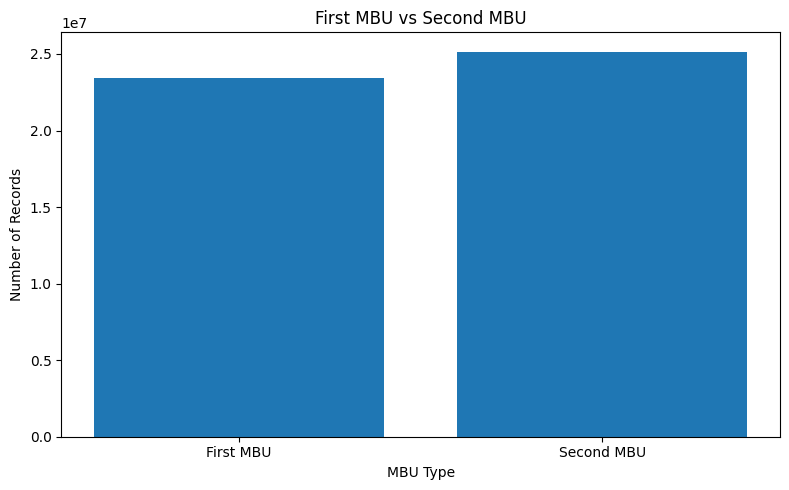

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(
    overall_mbu["MBU Type"],
    overall_mbu["Count"]
)

plt.xlabel("MBU Type")
plt.ylabel("Number of Records")
plt.title("First MBU vs Second MBU")

plt.tight_layout()

plt.savefig(
    "/content/first_vs_second_mbu.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
q25 = district_analysis["total_mbu"].quantile(0.25)
q50 = district_analysis["total_mbu"].quantile(0.50)
q75 = district_analysis["total_mbu"].quantile(0.75)

def classify_risk(value):
    if value <= q25:
        return "Low"
    elif value <= q50:
        return "Medium"
    elif value <= q75:
        return "High"
    else:
        return "Very High"

district_analysis["risk_category"] = (
    district_analysis["total_mbu"].apply(classify_risk)
)

district_analysis.head()

,state,district,first_mbu,second_mbu,total_mbu,risk_category
539,Maharashtra,Pune,177468,223803,401271,Very High
535,Maharashtra,Nashik,142839,227438,370277,Very High
548,Maharashtra,Thane,117045,238633,355678,Very High
229,Gujarat,Ahmedabad,124112,188348,312460,Very High
523,Maharashtra,Jalgaon,100056,178830,278886,Very High


In [28]:
risk_summary = (
    district_analysis["risk_category"]
    .value_counts()
    .reindex(["Low", "Medium", "High", "Very High"])
)

print(risk_summary)

risk_category
Low          258
Medium       258
High         258
Very High    258
Name: count, dtype: int64


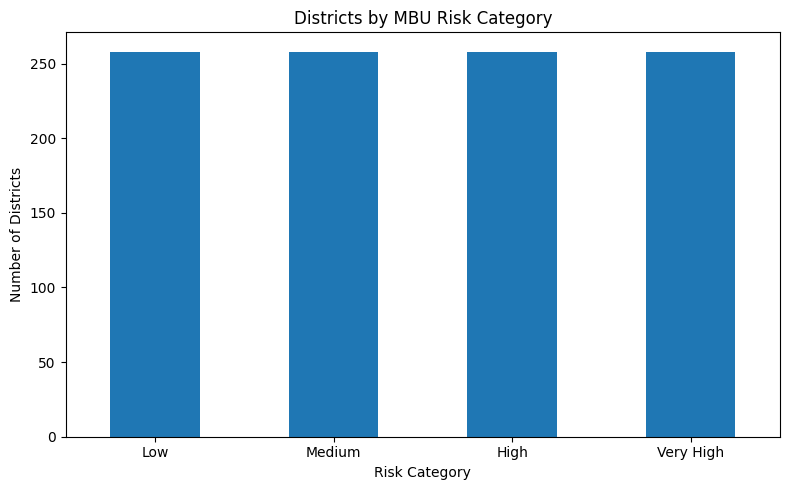

In [29]:
risk_summary.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Risk Category")
plt.ylabel("Number of Districts")
plt.title("Districts by MBU Risk Category")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "/content/district_risk_categories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
very_high = (
    district_analysis[
        district_analysis["risk_category"] == "Very High"
    ]
    .sort_values("total_mbu", ascending=False)
)

print(
    very_high[
        ["state", "district", "total_mbu", "risk_category"]
    ].head(20).to_string(index=False)
)

         state         district  total_mbu risk_category
   Maharashtra             Pune     401271     Very High
   Maharashtra           Nashik     370277     Very High
   Maharashtra            Thane     355678     Very High
       Gujarat        Ahmedabad     312460     Very High
   Maharashtra          Jalgaon     278886     Very High
   Maharashtra           Mumbai     255617     Very High
         Delhi North West Delhi     255510     Very High
     Rajasthan           Jaipur     253468     Very High
Andhra Pradesh          Kurnool     249235     Very High
   Maharashtra           Nagpur     236162     Very High
   Maharashtra          Solapur     228939     Very High
Andhra Pradesh    Visakhapatnam     226913     Very High
   Maharashtra           Nanded     226452     Very High
   Maharashtra       Ahmadnagar     226423     Very High
   Maharashtra         Amravati     225451     Very High
     Karnataka        Bengaluru     216421     Very High
       Gujarat            Surat

In [31]:
total_mbu_all = df["total_mbu"].sum()

district_analysis["mbu_share_percent"] = (
    district_analysis["total_mbu"] / total_mbu_all * 100
)

district_analysis = district_analysis.sort_values(
    "mbu_share_percent",
    ascending=False
)

district_analysis[
    ["state", "district", "total_mbu", "mbu_share_percent"]
].head(20)

,state,district,total_mbu,mbu_share_percent
539,Maharashtra,Pune,401271,0.825906
535,Maharashtra,Nashik,370277,0.762113
548,Maharashtra,Thane,355678,0.732065
229,Gujarat,Ahmedabad,312460,0.643113
523,Maharashtra,Jalgaon,278886,0.574010
527,Maharashtra,Mumbai,255617,0.526117
218,Delhi,North West Delhi,255510,0.525897
739,Rajasthan,Jaipur,253468,0.521694
28,Andhra Pradesh,Kurnool,249235,0.512982
531,Maharashtra,Nagpur,236162,0.486074


In [33]:
Q1 = district_analysis["total_mbu"].quantile(0.25)
Q3 = district_analysis["total_mbu"].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

outliers = district_analysis[
    district_analysis["total_mbu"] > upper_limit
].sort_values(
    "total_mbu",
    ascending=False
)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper outlier limit:", upper_limit)
print("Number of outlier districts:", len(outliers))

print("\nTop outlier districts:")
print(
    outliers[
        ["state", "district", "total_mbu"]
    ].head(20).to_string(index=False)
)

Q1: 2969.25
Q3: 71565.5
IQR: 68596.25
Upper outlier limit: 174459.875
Number of outlier districts: 27

Top outlier districts:
         state         district  total_mbu
   Maharashtra             Pune     401271
   Maharashtra           Nashik     370277
   Maharashtra            Thane     355678
       Gujarat        Ahmedabad     312460
   Maharashtra          Jalgaon     278886
   Maharashtra           Mumbai     255617
         Delhi North West Delhi     255510
     Rajasthan           Jaipur     253468
Andhra Pradesh          Kurnool     249235
   Maharashtra           Nagpur     236162
   Maharashtra          Solapur     228939
Andhra Pradesh    Visakhapatnam     226913
   Maharashtra           Nanded     226452
   Maharashtra       Ahmadnagar     226423
   Maharashtra         Amravati     225451
     Karnataka        Bengaluru     216421
       Gujarat            Surat     207376
   Maharashtra       Aurangabad     204831
Andhra Pradesh    East Godavari     204117
Andhra Pradesh

In [34]:
outliers[
    ["state", "district", "total_mbu", "mbu_share_percent"]
].to_csv(
    "/content/mbu_outlier_districts.csv",
    index=False
)

print(outliers[
    ["state", "district", "total_mbu", "mbu_share_percent"]
].to_string(index=False))

         state         district  total_mbu  mbu_share_percent
   Maharashtra             Pune     401271           0.825906
   Maharashtra           Nashik     370277           0.762113
   Maharashtra            Thane     355678           0.732065
       Gujarat        Ahmedabad     312460           0.643113
   Maharashtra          Jalgaon     278886           0.574010
   Maharashtra           Mumbai     255617           0.526117
         Delhi North West Delhi     255510           0.525897
     Rajasthan           Jaipur     253468           0.521694
Andhra Pradesh          Kurnool     249235           0.512982
   Maharashtra           Nagpur     236162           0.486074
   Maharashtra          Solapur     228939           0.471208
Andhra Pradesh    Visakhapatnam     226913           0.467038
   Maharashtra           Nanded     226452           0.466089
   Maharashtra       Ahmadnagar     226423           0.466029
   Maharashtra         Amravati     225451           0.464029
     Kar

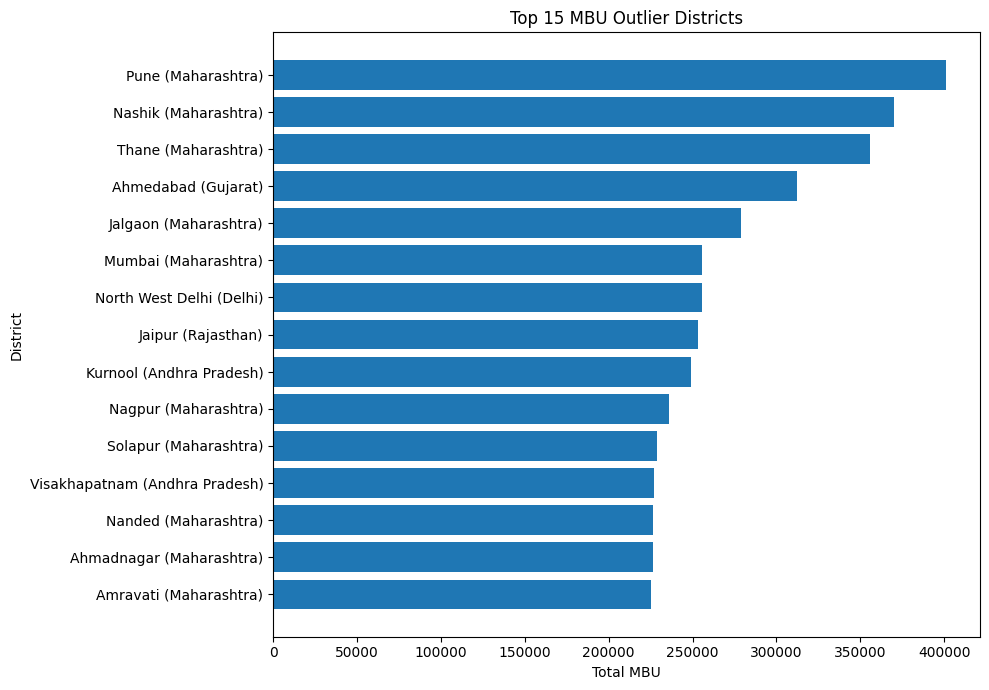

In [35]:
top_outliers = outliers.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_outliers["district"] + " (" + top_outliers["state"] + ")",
    top_outliers["total_mbu"]
)

plt.xlabel("Total MBU")
plt.ylabel("District")
plt.title("Top 15 MBU Outlier Districts")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "/content/top_15_mbu_outliers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
monthly_mbu = (
    df.set_index("date")
      .resample("ME")["total_mbu"]
      .sum()
      .reset_index()
)

monthly_mbu.head()

,date,total_mbu
0,2025-03-31,8322222
1,2025-04-30,8641679
2,2025-05-31,7879956
3,2025-06-30,7899289
4,2025-07-31,9792552


In [37]:
print("Number of months:", len(monthly_mbu))

print("\nHighest MBU month:")
print(
    monthly_mbu.loc[
        monthly_mbu["total_mbu"].idxmax()
    ]
)

print("\nLowest MBU month:")
print(
    monthly_mbu.loc[
        monthly_mbu["total_mbu"].idxmin()
    ]
)

Number of months: 7

Highest MBU month:
date         2025-07-31 00:00:00
total_mbu                9792552
Name: 4, dtype: object

Lowest MBU month:
date         2025-08-31 00:00:00
total_mbu                      0
Name: 5, dtype: object


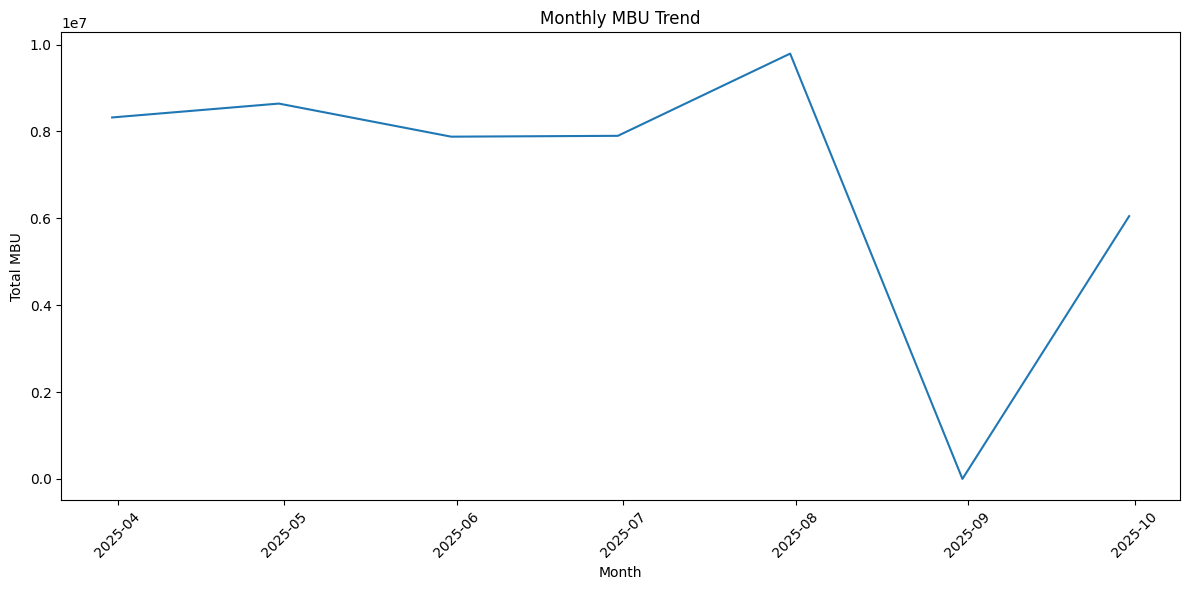

In [38]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_mbu["date"],
    monthly_mbu["total_mbu"]
)

plt.xlabel("Month")
plt.ylabel("Total MBU")
plt.title("Monthly MBU Trend")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "/content/monthly_mbu_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
monthly_mbu["mom_growth_percent"] = (
    monthly_mbu["total_mbu"].pct_change() * 100
)

monthly_mbu.head()

,date,total_mbu,mom_growth_percent
0,2025-03-31,8322222,NaN
1,2025-04-30,8641679,3.838602
2,2025-05-31,7879956,-8.814526
3,2025-06-30,7899289,0.245344
4,2025-07-31,9792552,23.967512


In [40]:
highest_growth = (
    monthly_mbu
    .dropna()
    .sort_values("mom_growth_percent", ascending=False)
    .head(10)
)

print(
    highest_growth[
        ["date", "total_mbu", "mom_growth_percent"]
    ].to_string(index=False)
)

      date  total_mbu  mom_growth_percent
2025-09-30    6049870                 inf
2025-07-31    9792552           23.967512
2025-04-30    8641679            3.838602
2025-06-30    7899289            0.245344
2025-05-31    7879956           -8.814526
2025-08-31          0         -100.000000


In [41]:
lowest_growth = (
    monthly_mbu
    .dropna()
    .sort_values("mom_growth_percent")
    .head(10)
)

print(
    lowest_growth[
        ["date", "total_mbu", "mom_growth_percent"]
    ].to_string(index=False)
)

      date  total_mbu  mom_growth_percent
2025-08-31          0         -100.000000
2025-05-31    7879956           -8.814526
2025-06-30    7899289            0.245344
2025-04-30    8641679            3.838602
2025-07-31    9792552           23.967512
2025-09-30    6049870                 inf


In [42]:
total_records = len(df)
total_mbu = df["total_mbu"].sum()
first_mbu = df["bio_age_5_17"].sum()
second_mbu = df["bio_age_17_"].sum()

top_state = state_analysis.iloc[0]["state"]
top_state_mbu = state_analysis.iloc[0]["total_mbu"]

top_district = district_analysis.iloc[0]["district"]
top_district_state = district_analysis.iloc[0]["state"]
top_district_mbu = district_analysis.iloc[0]["total_mbu"]

print("===== AADHAAR MBU ANALYTICS =====")
print("Clean records:", f"{total_records:,}")
print("First MBU:", f"{first_mbu:,}")
print("Second MBU:", f"{second_mbu:,}")
print("Total MBU:", f"{total_mbu:,}")
print("Top state:", top_state, f"({top_state_mbu:,})")
print(
    "Top district:",
    f"{top_district}, {top_district_state}",
    f"({top_district_mbu:,})"
)
print("Outlier districts:", len(outliers))

===== AADHAAR MBU ANALYTICS =====
Clean records: 489,682
First MBU: 23,430,272
Second MBU: 25,155,296
Total MBU: 48,585,568
Top state: Uttar Pradesh (6,643,629)
Top district: Pune, Maharashtra (401,271)
Outlier districts: 27


In [43]:
first_percent = first_mbu / total_mbu * 100
second_percent = second_mbu / total_mbu * 100

print(f"First MBU share: {first_percent:.2f}%")
print(f"Second MBU share: {second_percent:.2f}%")

First MBU share: 48.22%
Second MBU share: 51.78%


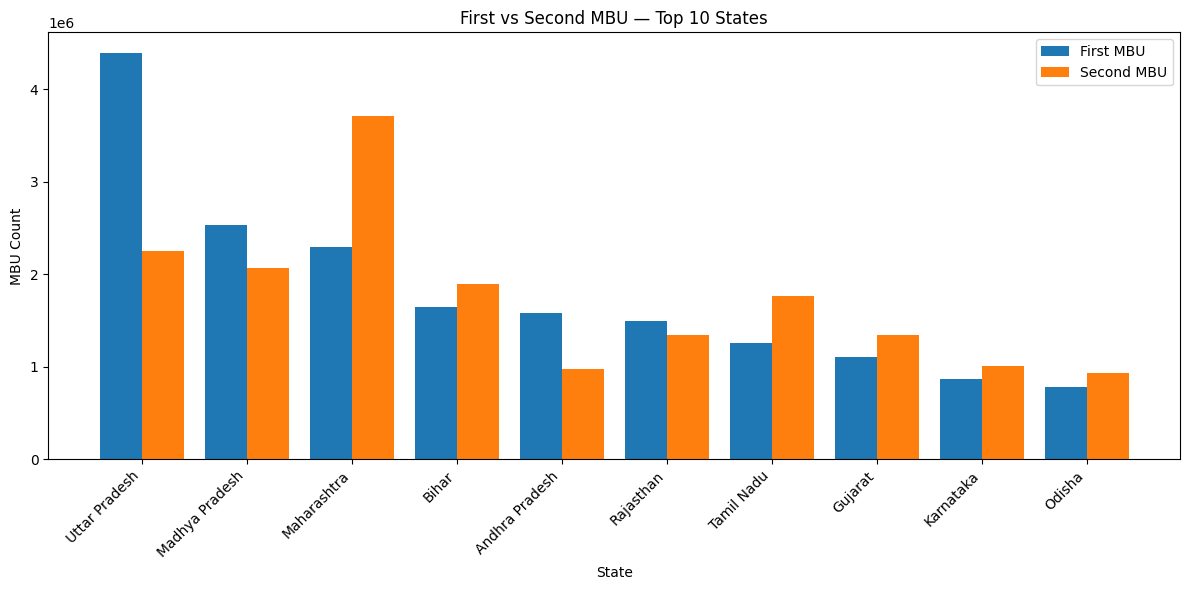

In [44]:
top_10_states = (
    mbu_comparison
    .sort_values("first_mbu", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

x = range(len(top_10_states))

plt.bar(
    [i - 0.2 for i in x],
    top_10_states["first_mbu"],
    width=0.4,
    label="First MBU"
)

plt.bar(
    [i + 0.2 for i in x],
    top_10_states["second_mbu"],
    width=0.4,
    label="Second MBU"
)

plt.xticks(
    x,
    top_10_states["state"],
    rotation=45,
    ha="right"
)

plt.xlabel("State")
plt.ylabel("MBU Count")
plt.title("First vs Second MBU — Top 10 States")
plt.legend()

plt.tight_layout()

plt.savefig(
    "/content/top_10_states_mbu_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
df.to_csv(
    "/content/aadhaar_mbu_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Cleaned dataset saved successfully!
Rows: 489682
Columns: 7
